In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not detected by PyTorch")

PyTorch version: 2.11.0+cpu
CUDA available: False
GPU not detected by PyTorch


In [3]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.4 MB/s eta 0:00:00


In [4]:
import os

os.makedirs("/content/civora_ai/models", exist_ok=True)

print("Model folder created:", os.path.exists("/content/civora_ai/models"))

Model folder created: True


In [5]:
from google.colab import files

uploaded = files.upload()

Saving garbage_best.pt to garbage_best.pt
Saving streetlight_best.pt to streetlight_best.pt
Saving pothole_best.pt to pothole_best.pt


In [6]:
from ultralytics import YOLO

# Load the trained models
garbage_model = YOLO("garbage_best.pt")
pothole_model = YOLO("pothole_best.pt")
streetlight_model = YOLO("streetlight_best.pt")

print("All 3 models loaded successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All 3 models loaded successfully!


In [9]:
from google.colab import files

uploaded = files.upload()

Saving img-43_jpg.rf.a63cf022f8ba7dbadc62c5d274547b79.jpg to img-43_jpg.rf.a63cf022f8ba7dbadc62c5d274547b79.jpg


In [10]:
results = pothole_model.predict(
    source="img-43_jpg.rf.a63cf022f8ba7dbadc62c5d274547b79.jpg",
    conf=0.5,
    device="cpu"
)

print("Pothole model prediction completed!")


image 1/1 /content/img-43_jpg.rf.a63cf022f8ba7dbadc62c5d274547b79.jpg: 640x640 2 potholes, 546.3ms
Speed: 22.2ms preprocess, 546.3ms inference, 52.7ms postprocess per image at shape (1, 3, 640, 640)
Pothole model prediction completed!


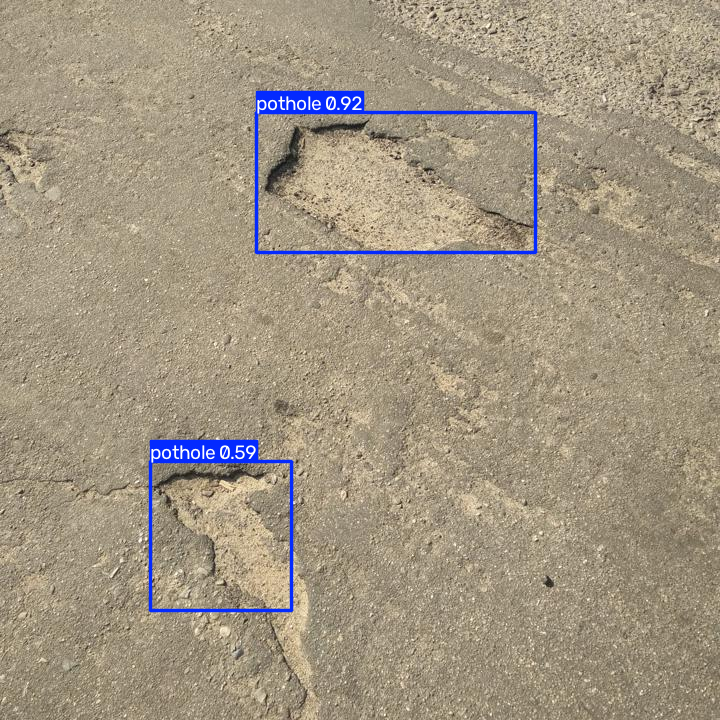

In [11]:
results[0].show()

In [12]:
import os

image_path = "/content/" + list(uploaded.keys())[0]

print("Testing image:", image_path)

Testing image: /content/img-43_jpg.rf.a63cf022f8ba7dbadc62c5d274547b79.jpg


In [13]:
def detect_issue(image_path):

    models = {
        "Garbage": garbage_model,
        "Streetlight": streetlight_model,
        "Pothole": pothole_model
    }

    detections = []

    for issue, model in models.items():

        results = model.predict(
            source=image_path,
            conf=0.25,
            verbose=False
        )

        for result in results:
            if result.boxes is not None and len(result.boxes) > 0:

                for box in result.boxes:
                    confidence = float(box.conf[0])

                    detections.append({
                        "issue": issue,
                        "confidence": round(confidence, 3)
                    })

    return detections

In [14]:
detections = detect_issue(image_path)

print("AI Detection Results:")
print(detections)

AI Detection Results:
[{'issue': 'Garbage', 'confidence': 0.355}, {'issue': 'Garbage', 'confidence': 0.332}, {'issue': 'Pothole', 'confidence': 0.915}, {'issue': 'Pothole', 'confidence': 0.588}, {'issue': 'Pothole', 'confidence': 0.373}]


In [15]:
def assign_priority(confidence):
    if confidence >= 0.80:
        return "High"
    elif confidence >= 0.50:
        return "Medium"
    else:
        return "Low"


def assign_department(issue):
    departments = {
        "Garbage": "Municipal Corporation",
        "Streetlight": "Electrical Department",
        "Pothole": "PWD"
    }
    return departments.get(issue, "Municipal Corporation")


final_results = []

for detection in detections:

    if detection["confidence"] >= 0.50:

        issue = detection["issue"]
        confidence = detection["confidence"]

        final_results.append({
            "issue": issue,
            "confidence": confidence,
            "priority": assign_priority(confidence),
            "department": assign_department(issue),
            "status": "Pending"
        })

print("========== CIVORA AI RESULT ==========")

for result in final_results:
    print(result)

========== CIVORA AI RESULT ==========
{'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'status': 'Pending'}
{'issue': 'Pothole', 'confidence': 0.588, 'priority': 'Medium', 'department': 'PWD', 'status': 'Pending'}


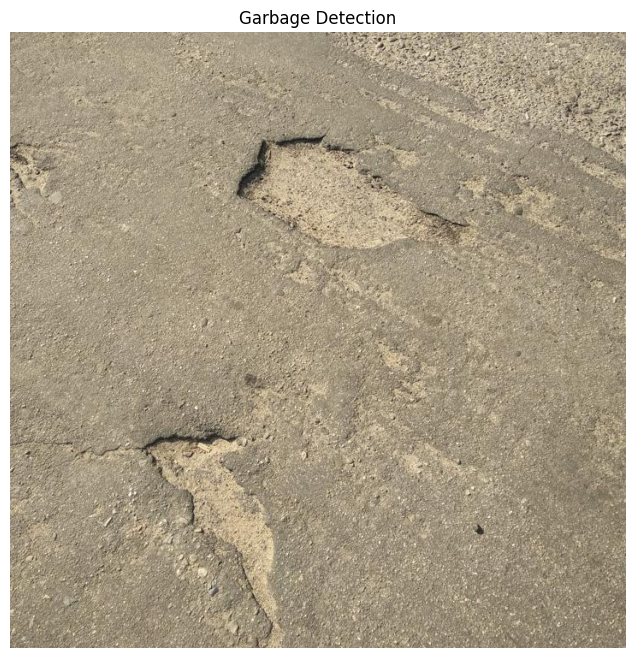

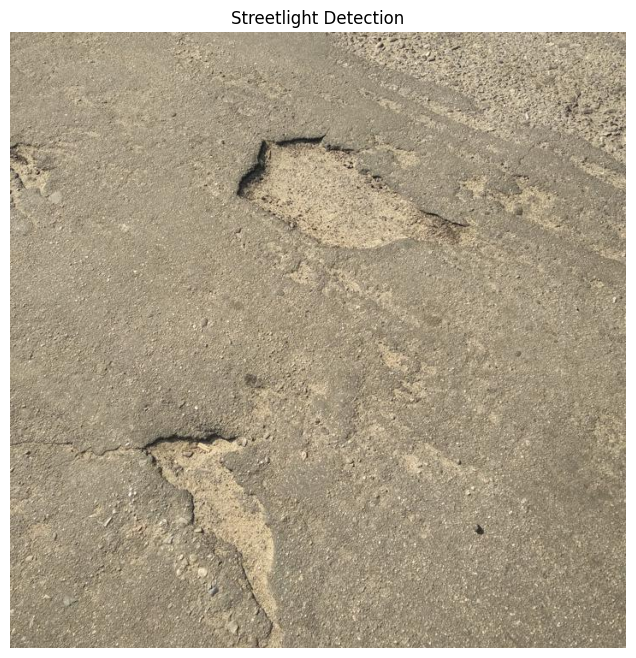

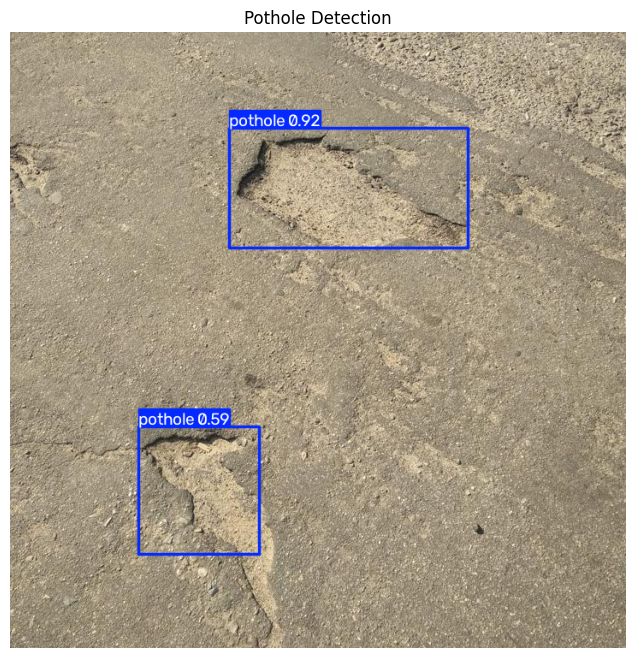

In [16]:
import matplotlib.pyplot as plt

for issue, model in {
    "Garbage": garbage_model,
    "Streetlight": streetlight_model,
    "Pothole": pothole_model
}.items():

    results = model.predict(
        source=image_path,
        conf=0.50,
        verbose=False
    )

    for result in results:
        annotated_image = result.plot()

        plt.figure(figsize=(12, 8))
        plt.imshow(annotated_image[:, :, ::-1])
        plt.title(f"{issue} Detection")
        plt.axis("off")
        plt.show()

In [17]:
final_detections = []

models = {
    "Garbage": garbage_model,
    "Streetlight": streetlight_model,
    "Pothole": pothole_model
}

for issue, model in models.items():

    results = model.predict(
        source=image_path,
        conf=0.50,
        device="cpu",
        verbose=False
    )

    for result in results:

        if result.boxes is None:
            continue

        for box in result.boxes:

            confidence = float(box.conf[0])

            if confidence >= 0.50:

                final_detections.append({
                    "issue": issue,
                    "confidence": round(confidence, 3)
                })

print("Final AI Detection Results:")
print(final_detections)

Final AI Detection Results:
[{'issue': 'Pothole', 'confidence': 0.915}, {'issue': 'Pothole', 'confidence': 0.588}]


In [18]:
best_detections = {}

for detection in final_detections:

    issue = detection["issue"]
    confidence = detection["confidence"]

    if issue not in best_detections:
        best_detections[issue] = detection

    elif confidence > best_detections[issue]["confidence"]:
        best_detections[issue] = detection

final_result = list(best_detections.values())

print("Final Result:")
print(final_result)

Final Result:
[{'issue': 'Pothole', 'confidence': 0.915}]


In [19]:
final_detections = []

models = {
    "Garbage": garbage_model,
    "Streetlight": streetlight_model,
    "Pothole": pothole_model
}

for issue, model in models.items():

    results = model.predict(
        source=image_path,
        conf=0.50,
        device="cpu",
        verbose=False
    )

    for result in results:

        if result.boxes is None:
            continue

        for box in result.boxes:

            confidence = float(box.conf[0])

            if confidence >= 0.50:

                x1, y1, x2, y2 = map(
                    int,
                    box.xyxy[0].tolist()
                )

                final_detections.append({
                    "issue": issue,
                    "confidence": round(confidence, 3),
                    "bbox": [x1, y1, x2, y2]
                })

print("Final Detection:")
print(final_detections)

Final Detection:
[{'issue': 'Pothole', 'confidence': 0.915, 'bbox': [256, 112, 535, 252]}, {'issue': 'Pothole', 'confidence': 0.588, 'bbox': [150, 461, 291, 610]}]


In [22]:
import uuid

def assign_priority(confidence):
    if confidence >= 0.80:
        return "High"
    elif confidence >= 0.60:
        return "Medium"
    else:
        return "Low"

def assign_department(issue):
    departments = {
        "Garbage": "Municipal Corporation",
        "Streetlight": "Electrical Department",
        "Pothole": "PWD"
    }
    return departments[issue]

def generate_complaint_id(issue):
    prefixes = {
        "Garbage": "GBG",
        "Streetlight": "STL",
        "Pothole": "PTH"
    }
    return prefixes[issue] + "-" + str(uuid.uuid4())[:6].upper()

In [23]:
import uuid

final_results = []

for detection in detections:

    issue = detection["issue"]
    confidence = detection["confidence"]

    if confidence >= 0.80:
        priority = "High"
    elif confidence >= 0.60:
        priority = "Medium"
    else:
        priority = "Low"

    departments = {
        "Garbage": "Municipal Corporation",
        "Streetlight": "Electrical Department",
        "Pothole": "PWD"
    }

    prefixes = {
        "Garbage": "GBG",
        "Streetlight": "STL",
        "Pothole": "PTH"
    }

    final_results.append({
        "complaint_id": prefixes[issue] + "-" + str(uuid.uuid4())[:6].upper(),
        "issue": issue,
        "confidence": confidence,
        "priority": priority,
        "department": departments[issue],
        "status": "Pending"
    })

print("========== CIVORA AI RESULT ==========")

for result in final_results:
    print(result)

========== CIVORA AI RESULT ==========
{'complaint_id': 'GBG-D6FDE0', 'issue': 'Garbage', 'confidence': 0.355, 'priority': 'Low', 'department': 'Municipal Corporation', 'status': 'Pending'}
{'complaint_id': 'GBG-0FCA3B', 'issue': 'Garbage', 'confidence': 0.332, 'priority': 'Low', 'department': 'Municipal Corporation', 'status': 'Pending'}
{'complaint_id': 'PTH-CF0A88', 'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'status': 'Pending'}
{'complaint_id': 'PTH-616F24', 'issue': 'Pothole', 'confidence': 0.588, 'priority': 'Low', 'department': 'PWD', 'status': 'Pending'}
{'complaint_id': 'PTH-13A4E8', 'issue': 'Pothole', 'confidence': 0.373, 'priority': 'Low', 'department': 'PWD', 'status': 'Pending'}


In [24]:
import pandas as pd

civora_df = pd.DataFrame(final_results)

civora_df["confidence"] = (civora_df["confidence"] * 100).round(1).astype(str) + "%"

display(civora_df)

,complaint_id,issue,confidence,priority,department,status
0,GBG-D6FDE0,Garbage,35.5%,Low,Municipal Corporation,Pending
1,GBG-0FCA3B,Garbage,33.2%,Low,Municipal Corporation,Pending
2,PTH-CF0A88,Pothole,91.5%,High,PWD,Pending
3,PTH-616F24,Pothole,58.8%,Low,PWD,Pending
4,PTH-13A4E8,Pothole,37.3%,Low,PWD,Pending


In [25]:
location = {
    "latitude": 19.0760,
    "longitude": 72.8777,
    "area": "Mumbai"
}

for result in final_results:
    result["latitude"] = location["latitude"]
    result["longitude"] = location["longitude"]
    result["area"] = location["area"]

print(final_results)

[{'complaint_id': 'GBG-D6FDE0', 'issue': 'Garbage', 'confidence': 0.355, 'priority': 'Low', 'department': 'Municipal Corporation', 'status': 'Pending', 'latitude': 19.076, 'longitude': 72.8777, 'area': 'Mumbai'}, {'complaint_id': 'GBG-0FCA3B', 'issue': 'Garbage', 'confidence': 0.332, 'priority': 'Low', 'department': 'Municipal Corporation', 'status': 'Pending', 'latitude': 19.076, 'longitude': 72.8777, 'area': 'Mumbai'}, {'complaint_id': 'PTH-CF0A88', 'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'status': 'Pending', 'latitude': 19.076, 'longitude': 72.8777, 'area': 'Mumbai'}, {'complaint_id': 'PTH-616F24', 'issue': 'Pothole', 'confidence': 0.588, 'priority': 'Low', 'department': 'PWD', 'status': 'Pending', 'latitude': 19.076, 'longitude': 72.8777, 'area': 'Mumbai'}, {'complaint_id': 'PTH-13A4E8', 'issue': 'Pothole', 'confidence': 0.373, 'priority': 'Low', 'department': 'PWD', 'status': 'Pending', 'latitude': 19.076, 'longitude': 72.8777, 'area': 'Mu

In [29]:
# Select the detection with the highest confidence
best_detection = max(
    final_detections,
    key=lambda x: x["confidence"]
)

print("Best Detection:")
print(best_detection)

Best Detection:
{'issue': 'Pothole', 'confidence': 0.915, 'bbox': [256, 112, 535, 252]}


In [30]:
print("Issue:", best_detection["issue"])
print("Confidence:", best_detection["confidence"])
print("Bounding Box:", best_detection["bbox"])

Issue: Pothole
Confidence: 0.915
Bounding Box: [256, 112, 535, 252]


In [32]:
def recommend_department(issue):

    departments = {
        "Pothole": "PWD",
        "Garbage": "Sanitation",
        "Streetlight": "Electrical",
        "Water Leakage": "Water Board",
        "Drainage": "Municipal Corporation"
    }

    return departments.get(issue, "Municipal Corporation")

print("Department function loaded successfully!")

Department function loaded successfully!


In [33]:
def predict_priority(issue, confidence, detection_count=1):

    if issue == "Pothole":
        if confidence >= 0.90:
            return "High"
        elif confidence >= 0.70:
            return "Medium"
        else:
            return "Low"

    elif issue == "Garbage":
        if detection_count >= 3:
            return "High"
        elif detection_count >= 1:
            return "Medium"
        else:
            return "Low"

    elif issue == "Streetlight":
        if confidence >= 0.90:
            return "High"
        elif confidence >= 0.70:
            return "Medium"
        else:
            return "Low"

    return "Medium"

print("Priority function loaded successfully!")

Priority function loaded successfully!


In [34]:
import uuid

issue = best_detection["issue"]
confidence = best_detection["confidence"]

priority = predict_priority(
    issue,
    confidence,
    detection_count=len(final_detections)
)

department = recommend_department(issue)

prefix = {
    "Pothole": "PTH",
    "Garbage": "GBG",
    "Streetlight": "STL"
}.get(issue, "CIV")

complaint_id = f"{prefix}-{uuid.uuid4().hex[:6].upper()}"

complaint = {
    "complaint_id": complaint_id,
    "issue": issue,
    "confidence": confidence,
    "priority": priority,
    "department": department,
    "status": "Pending",
    "latitude": 19.076,
    "longitude": 72.8777,
    "area": "Mumbai",
    "image": image_path
}

print("New Complaint:")
print(complaint)

New Complaint:
{'complaint_id': 'PTH-E95FE9', 'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'status': 'Pending', 'latitude': 19.076, 'longitude': 72.8777, 'area': 'Mumbai', 'image': '/content/img-43_jpg.rf.a63cf022f8ba7dbadc62c5d274547b79.jpg'}


In [ ]:
#duplicate

In [35]:
existing_complaints = [
    {
        "complaint_id": "PTH-OLD001",
        "issue": "Pothole",
        "latitude": 19.0762,
        "longitude": 72.8778
    },
    {
        "complaint_id": "GBG-OLD001",
        "issue": "Garbage",
        "latitude": 19.0800,
        "longitude": 72.8800
    }
]

print("Existing complaints loaded:")
print(existing_complaints)

Existing complaints loaded:
[{'complaint_id': 'PTH-OLD001', 'issue': 'Pothole', 'latitude': 19.0762, 'longitude': 72.8778}, {'complaint_id': 'GBG-OLD001', 'issue': 'Garbage', 'latitude': 19.08, 'longitude': 72.88}]


In [36]:
from math import radians, sin, cos, sqrt, atan2

def calculate_distance(lat1, lon1, lat2, lon2):

    R = 6371000  # Earth radius in meters

    lat1 = radians(lat1)
    lat2 = radians(lat2)

    dlat = lat2 - lat1
    dlon = radians(lon2 - lon1)

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

print("Distance function loaded!")

Distance function loaded!


In [37]:
def find_duplicate(
    new_complaint,
    existing_complaints,
    threshold=100
):

    for old_complaint in existing_complaints:

        # Issue must be the same
        if old_complaint["issue"] != new_complaint["issue"]:
            continue

        distance = calculate_distance(
            new_complaint["latitude"],
            new_complaint["longitude"],
            old_complaint["latitude"],
            old_complaint["longitude"]
        )

        # Same issue within 100 meters = duplicate
        if distance <= threshold:

            return {
                "is_duplicate": True,
                "duplicate_of": old_complaint["complaint_id"],
                "distance_meters": round(distance, 2)
            }

    return {
        "is_duplicate": False,
        "duplicate_of": None,
        "distance_meters": None
    }

print("Duplicate detection function loaded!")

Duplicate detection function loaded!


In [38]:
duplicate_result = find_duplicate(
    complaint,
    existing_complaints
)

print("Duplicate Detection Result:")
print(duplicate_result)

Duplicate Detection Result:
{'is_duplicate': True, 'duplicate_of': 'PTH-OLD001', 'distance_meters': 24.6}


In [39]:
complaint["duplicate"] = duplicate_result

print("FINAL CIVORA COMPLAINT:")
print(complaint)

FINAL CIVORA COMPLAINT:
{'complaint_id': 'PTH-E95FE9', 'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'status': 'Pending', 'latitude': 19.076, 'longitude': 72.8777, 'area': 'Mumbai', 'image': '/content/img-43_jpg.rf.a63cf022f8ba7dbadc62c5d274547b79.jpg', 'duplicate': {'is_duplicate': True, 'duplicate_of': 'PTH-OLD001', 'distance_meters': 24.6}}


In [40]:
final_ai_output = {
    "issue": complaint["issue"],
    "confidence": complaint["confidence"],
    "priority": complaint["priority"],
    "department": complaint["department"],
    "duplicate_group": complaint["duplicate"]["duplicate_of"]
}

print("================================")
print("       FINAL AI OUTPUT")
print("================================")
print(final_ai_output)

       FINAL AI OUTPUT
{'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'duplicate_group': 'PTH-OLD001'}


In [41]:
!pip install fastapi uvicorn python-multipart nest-asyncio -q

In [42]:
from fastapi import FastAPI, UploadFile, File
import nest_asyncio

app = FastAPI(
    title="CIVORA AI API",
    description="AI service for civic issue detection",
    version="1.0"
)

@app.get("/")
def home():
    return {
        "message": "CIVORA AI API is running"
    }

In [43]:
@app.post("/predict")
async def predict_issue(file: UploadFile = File(...)):

    return {
        "message": "Image received",
        "filename": file.filename
    }

In [46]:
import nest_asyncio
import uvicorn

nest_asyncio.apply()

config = uvicorn.Config(
    app,
    host="0.0.0.0",
    port=8000,
    log_level="info"
)

server = uvicorn.Server(config)

await server.serve()

INFO:     Started server process [3042]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [3042]


In [47]:
def run_civora_ai(image_path):

    detections = []

    models = {
        "Garbage": garbage_model,
        "Streetlight": streetlight_model,
        "Pothole": pothole_model
    }

    # Run the 3 models
    for issue, model in models.items():

        results = model.predict(
            source=image_path,
            conf=0.50,
            device="cpu",
            verbose=False
        )

        for result in results:

            if result.boxes is None:
                continue

            for box in result.boxes:

                confidence = float(box.conf[0])

                if confidence >= 0.50:

                    detections.append({
                        "issue": issue,
                        "confidence": round(confidence, 3)
                    })

    # If nothing detected
    if not detections:
        return {
            "issue": None,
            "confidence": 0,
            "priority": None,
            "department": None,
            "duplicate_group": None
        }

    # Choose highest confidence
    best = max(
        detections,
        key=lambda x: x["confidence"]
    )

    issue = best["issue"]
    confidence = best["confidence"]

    # Priority
    priority = predict_priority(
        issue,
        confidence,
        len(detections)
    )

    # Department
    department = recommend_department(issue)

    return {
        "issue": issue,
        "confidence": confidence,
        "priority": priority,
        "department": department,
        "duplicate_group": None
    }

print("CIVORA AI function created!")

CIVORA AI function created!


In [48]:
result = run_civora_ai(image_path)

print(result)

{'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'duplicate_group': None}


In [49]:
from fastapi import UploadFile, File
import os
import uuid

@app.post("/predict")
async def predict_issue(file: UploadFile = File(...)):

    # Create temporary filename
    file_name = f"/content/{uuid.uuid4()}_{file.filename}"

    # Save uploaded image
    with open(file_name, "wb") as buffer:
        buffer.write(await file.read())

    # Run CIVORA AI
    result = run_civora_ai(file_name)

    # Delete temporary image
    os.remove(file_name)

    # Return AI result
    return result

print("CIVORA /predict endpoint created!")

CIVORA /predict endpoint created!


In [50]:
for route in app.routes:
    print(route.path, route.methods)

/openapi.json {'HEAD', 'GET'}
/docs {'HEAD', 'GET'}
/docs/oauth2-redirect {'HEAD', 'GET'}
/redoc {'HEAD', 'GET'}
/ {'GET'}
/predict {'POST'}
/predict {'POST'}


In [51]:
from fastapi import FastAPI, UploadFile, File
import os
import uuid

app = FastAPI(
    title="CIVORA AI API",
    description="CIVORA AI Civic Issue Detection API",
    version="1.0"
)

@app.get("/")
def home():
    return {
        "message": "CIVORA AI API is running"
    }

@app.post("/predict")
async def predict_issue(file: UploadFile = File(...)):

    file_name = f"/content/{uuid.uuid4()}_{file.filename}"

    with open(file_name, "wb") as buffer:
        buffer.write(await file.read())

    result = run_civora_ai(file_name)

    os.remove(file_name)

    return result

print("Clean CIVORA API created!")

Clean CIVORA API created!


In [52]:
for route in app.routes:
    print(route.path, route.methods)

/openapi.json {'HEAD', 'GET'}
/docs {'HEAD', 'GET'}
/docs/oauth2-redirect {'HEAD', 'GET'}
/redoc {'HEAD', 'GET'}
/ {'GET'}
/predict {'POST'}


In [53]:
from fastapi.testclient import TestClient

client = TestClient(app)

with open(image_path, "rb") as image_file:

    response = client.post(
        "/predict",
        files={
            "file": (
                "test_image.jpg",
                image_file,
                "image/jpeg"
            )
        }
    )

print("Status Code:", response.status_code)
print("API Response:")
print(response.json())

Status Code: 200
API Response:
{'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'duplicate_group': None}


In [54]:
existing_complaints = [
    {
        "complaint_id": "PTH-OLD001",
        "issue": "Pothole",
        "latitude": 19.0762,
        "longitude": 72.8778
    },
    {
        "complaint_id": "GBG-OLD001",
        "issue": "Garbage",
        "latitude": 19.0800,
        "longitude": 72.8800
    }
]

print("Existing complaints loaded")

Existing complaints loaded


In [55]:
def run_civora_ai(image_path):

    detections = []

    models = {
        "Garbage": garbage_model,
        "Streetlight": streetlight_model,
        "Pothole": pothole_model
    }

    # Run all 3 models
    for issue, model in models.items():

        results = model.predict(
            source=image_path,
            conf=0.50,
            device="cpu",
            verbose=False
        )

        for result in results:

            if result.boxes is None:
                continue

            for box in result.boxes:

                confidence = float(box.conf[0])

                if confidence >= 0.50:

                    detections.append({
                        "issue": issue,
                        "confidence": round(confidence, 3)
                    })

    # No issue detected
    if not detections:
        return {
            "issue": None,
            "confidence": 0,
            "priority": None,
            "department": None,
            "duplicate_group": None
        }

    # Highest confidence detection
    best = max(
        detections,
        key=lambda x: x["confidence"]
    )

    issue = best["issue"]
    confidence = best["confidence"]

    # Priority
    priority = predict_priority(
        issue,
        confidence,
        len(detections)
    )

    # Department
    department = recommend_department(issue)

    # Create temporary complaint
    new_complaint = {
        "issue": issue,
        "confidence": confidence,
        "latitude": 19.076,
        "longitude": 72.8777
    }

    # Duplicate detection
    duplicate_result = find_duplicate(
        new_complaint,
        existing_complaints
    )

    return {
        "issue": issue,
        "confidence": confidence,
        "priority": priority,
        "department": department,
        "duplicate_group": duplicate_result["duplicate_of"]
    }

print("CIVORA AI updated with duplicate detection!")

CIVORA AI updated with duplicate detection!


In [56]:
result = run_civora_ai(image_path)

print("FINAL CIVORA RESULT:")
print(result)

FINAL CIVORA RESULT:
{'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'duplicate_group': 'PTH-OLD001'}


In [57]:
from fastapi.testclient import TestClient

client = TestClient(app)

with open(image_path, "rb") as image_file:

    response = client.post(
        "/predict",
        files={
            "file": (
                "test_image.jpg",
                image_file,
                "image/jpeg"
            )
        }
    )

print("Status Code:", response.status_code)
print("API Response:")
print(response.json())

Status Code: 200
API Response:
{'issue': 'Pothole', 'confidence': 0.915, 'priority': 'High', 'department': 'PWD', 'duplicate_group': 'PTH-OLD001'}


In [58]:
!pip install pyngrok

/usr/lib/python3.12/pathlib.py:404: RuntimeWarning: coroutine 'Server.serve' was never awaited
  parsed = [sys.intern(str(x)) for x in rel.split(sep) if x and x != '.']


In [59]:
from pyngrok import ngrok
import nest_asyncio
import threading
import uvicorn

nest_asyncio.apply()

# Start FastAPI server in background
def start_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=start_server, daemon=True)
server_thread.start()

print("FastAPI server starting...")

FastAPI server starting...


INFO:     Started server process [3042]


In [64]:
from pyngrok import ngrok

ngrok.set_auth_token("3I0BooAjXt86nSNcjl8TD02D5i2_87WHqkj55JmEvkGS3KZu4")

print("ngrok authentication configured")

ngrok authentication configured


In [65]:
public_url = ngrok.connect(8000)

print("CIVORA PUBLIC API URL:")
print(public_url)

CIVORA PUBLIC API URL:
NgrokTunnel: "https://goatskin-vessel-chant.ngrok-free.dev" -> "http://localhost:8000"
